<a href="https://colab.research.google.com/github/harshitt018/Advance-Data-Science/blob/main/Variational%20Autoencoders%20(VAEs).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Import Libraries**

In [1]:
# Install KaggleHub
!pip -q install kagglehub

# Core Libraries
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt

# Image Processing
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# TorchVision
from torchvision import transforms

# Dataset Download
import kagglehub

# Progress Bar
from tqdm import tqdm

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch Version:", torch.__version__)
print("Device:", device)

PyTorch Version: 2.11.0+cu128
Device: cuda


# **2. Download Dataset**

In [2]:
# Download Cat Dataset
path = kagglehub.dataset_download("crawford/cat-dataset")

print("Dataset Path:", path)

Using Colab cache for faster access to the 'cat-dataset' dataset.
Dataset Path: /kaggle/input/cat-dataset


# **3. Check Folder Structure**

In [3]:
# Check Folder Structure
for root, dirs, files in os.walk(path):
    print(f"{root} --> {len(files)} files")

/kaggle/input/cat-dataset --> 0 files
/kaggle/input/cat-dataset/CAT_03 --> 1623 files
/kaggle/input/cat-dataset/CAT_02 --> 3515 files
/kaggle/input/cat-dataset/CAT_00 --> 3413 files
/kaggle/input/cat-dataset/CAT_01 --> 3237 files
/kaggle/input/cat-dataset/CAT_06 --> 2777 files
/kaggle/input/cat-dataset/CAT_04 --> 2793 files
/kaggle/input/cat-dataset/CAT_05 --> 2643 files
/kaggle/input/cat-dataset/cats --> 0 files
/kaggle/input/cat-dataset/cats/CAT_03 --> 1623 files
/kaggle/input/cat-dataset/cats/CAT_02 --> 3515 files
/kaggle/input/cat-dataset/cats/CAT_00 --> 3413 files
/kaggle/input/cat-dataset/cats/CAT_01 --> 3237 files
/kaggle/input/cat-dataset/cats/CAT_06 --> 2777 files
/kaggle/input/cat-dataset/cats/CAT_04 --> 2793 files
/kaggle/input/cat-dataset/cats/CAT_05 --> 2643 files


# **4. Collect All JPG Images**

In [4]:
# Collect All JPG Images
image_paths = []

for folder in ["CAT_00", "CAT_01", "CAT_02", "CAT_03", "CAT_04", "CAT_05", "CAT_06"]:
    image_paths.extend(
        glob.glob(os.path.join(path, folder, "*.jpg"))
    )

print("Total Images:", len(image_paths))
print("Sample Image:", image_paths[0])

Total Images: 9997
Sample Image: /kaggle/input/cat-dataset/CAT_00/00000378_025.jpg


# **5. Displaying sample images from Dataset**

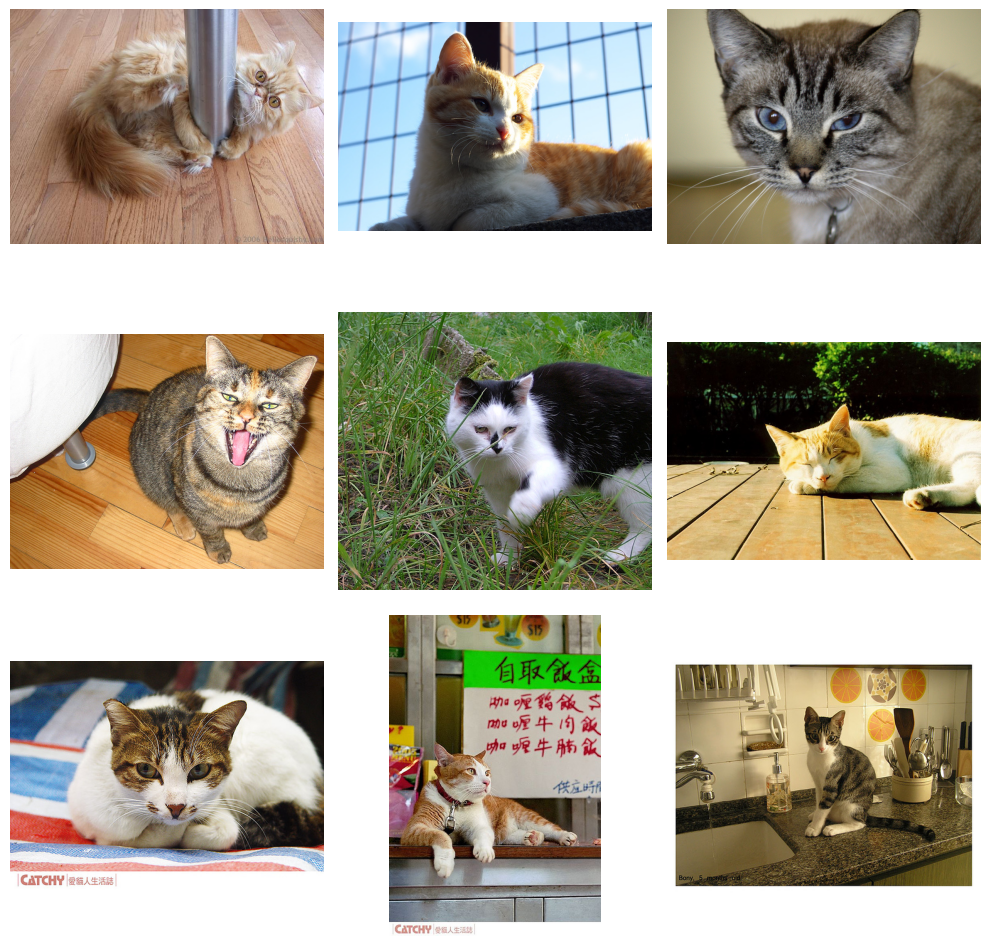

In [5]:
# Visualize Random Cat Images
sample_images = random.sample(image_paths, 9)

plt.figure(figsize=(10, 10))

for i, img_path in enumerate(sample_images):
    img = Image.open(img_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

# **6. Image Transform**

In [6]:
# Image Transform
IMG_SIZE = 64

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

# Test Transform

img = Image.open(image_paths[0]).convert("RGB")
img_tensor = transform(img)

print("Image Shape:", img_tensor.shape)
print("Min Value:", img_tensor.min().item())
print("Max Value:", img_tensor.max().item())

Image Shape: torch.Size([3, 64, 64])
Min Value: 0.054901961237192154
Max Value: 1.0


# **7. Custom Dataset**

In [7]:
class CatDataset(Dataset):

    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        img = Image.open(self.image_paths[idx]).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img


dataset = CatDataset(
    image_paths=image_paths,
    transform=transform
)

print("Dataset Size:", len(dataset))

sample = dataset[0]

print("Sample Shape:", sample.shape)

Dataset Size: 9997
Sample Shape: torch.Size([3, 64, 64])


# **8. Create DataLoader**

In [8]:
BATCH_SIZE = 64

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

batch = next(iter(dataloader))

print("Batch Shape:", batch.shape)

Batch Shape: torch.Size([64, 3, 64, 64])


# **Cell 9. VAE Hyperparameters**

In [9]:
IMG_SIZE = 64
CHANNELS = 3

LATENT_DIM = 128

LEARNING_RATE = 1e-4
EPOCHS = 50

# **10. Build Encoder**

In [10]:
class Encoder(nn.Module):

    def __init__(self, latent_dim=128):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(256 * 4 * 4, latent_dim)

    def forward(self, x):

        x = self.conv(x)

        x = x.view(x.size(0), -1)

        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)

        return mu, logvar

# **11. Test Encoder**

In [11]:
encoder = Encoder(LATENT_DIM).to(device)

mu, logvar = encoder(batch.to(device))

print("Mu Shape:", mu.shape)
print("LogVar Shape:", logvar.shape)

Mu Shape: torch.Size([64, 128])
LogVar Shape: torch.Size([64, 128])


# **12. Build Decoder**

In [12]:
class Decoder(nn.Module):

    def __init__(self, latent_dim=128):
        super().__init__()

        self.fc = nn.Linear(latent_dim, 256 * 4 * 4)

        self.deconv = nn.Sequential(

            nn.ConvTranspose2d(
                256, 128,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose2d(
                128, 64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose2d(
                64, 32,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose2d(
                32, 3,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.Sigmoid()
        )

    def forward(self, z):

        x = self.fc(z)

        x = x.view(-1, 256, 4, 4)

        x = self.deconv(x)

        return x

# **13. Test Decoder**

In [13]:
decoder = Decoder(LATENT_DIM).to(device)

z = torch.randn(64, LATENT_DIM).to(device)

output = decoder(z)

print("Output Shape:", output.shape)

Output Shape: torch.Size([64, 3, 64, 64])


# **14. Reparameterization Layer**

In [14]:
class VAE(nn.Module):

    def __init__(self, latent_dim=128):
        super().__init__()

        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5 * logvar)

        eps = torch.randn_like(std)

        return mu + eps * std

    def forward(self, x):

        mu, logvar = self.encoder(x)

        z = self.reparameterize(mu, logvar)

        reconstructed = self.decoder(z)

        return reconstructed, mu, logvar

# **15. Initialize VAE**

In [15]:
model = VAE(LATENT_DIM).to(device)

print(model)

VAE(
  (encoder): Encoder(
    (conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (5): ReLU()
      (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (7): ReLU()
    )
    (fc_mu): Linear(in_features=4096, out_features=128, bias=True)
    (fc_logvar): Linear(in_features=4096, out_features=128, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=128, out_features=4096, bias=True)
    (deconv): Sequential(
      (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (5):

# **16. Test Full VAE**

In [16]:
batch = batch.to(device)

reconstructed, mu, logvar = model(batch)

print("Input Shape:", batch.shape)
print("Reconstructed Shape:", reconstructed.shape)
print("Mu Shape:", mu.shape)
print("LogVar Shape:", logvar.shape)

Input Shape: torch.Size([64, 3, 64, 64])
Reconstructed Shape: torch.Size([64, 3, 64, 64])
Mu Shape: torch.Size([64, 128])
LogVar Shape: torch.Size([64, 128])


# **17. VAE Loss Function**

In [17]:
def vae_loss(reconstructed, original, mu, logvar):

    reconstruction_loss = F.mse_loss(
        reconstructed,
        original,
        reduction="sum"
    )

    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    total_loss = reconstruction_loss + kl_loss

    return total_loss, reconstruction_loss, kl_loss

# **18. Test Loss Function**

In [18]:
total_loss, recon_loss, kl_loss = vae_loss(
    reconstructed,
    batch,
    mu,
    logvar
)

print("Total Loss :", total_loss.item())
print("Recon Loss :", recon_loss.item())
print("KL Loss    :", kl_loss.item())

Total Loss : 60620.6171875
Recon Loss : 60619.17578125
KL Loss    : 1.4423846006393433


# **19. Optimizer**

In [19]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Optimizer Ready")

Optimizer Ready


# **20. Training Function**

In [20]:
def train_epoch(model, dataloader, optimizer):

    model.train()

    total_loss = 0
    total_recon = 0
    total_kl = 0

    for images in tqdm(dataloader):

        images = images.to(device)

        optimizer.zero_grad()

        reconstructed, mu, logvar = model(images)

        loss, recon_loss, kl_loss = vae_loss(
            reconstructed,
            images,
            mu,
            logvar
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    avg_loss = total_loss / len(dataset)
    avg_recon = total_recon / len(dataset)
    avg_kl = total_kl / len(dataset)

    return avg_loss, avg_recon, avg_kl

# **21. Create History Lists**

In [21]:
train_losses = []
recon_losses = []
kl_losses = []

# **22. Train VAE Model**

In [22]:
for epoch in range(EPOCHS):

    avg_loss, avg_recon, avg_kl = train_epoch(
        model,
        dataloader,
        optimizer
    )

    train_losses.append(avg_loss)
    recon_losses.append(avg_recon)
    kl_losses.append(avg_kl)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Loss: {avg_loss:.4f} | "
        f"Recon: {avg_recon:.4f} | "
        f"KL: {avg_kl:.4f}"
    )

100%|██████████| 157/157 [01:21<00:00,  1.92it/s]


Epoch [1/50] | Loss: 764.7860 | Recon: 751.3581 | KL: 13.4279


100%|██████████| 157/157 [00:56<00:00,  2.80it/s]


Epoch [2/50] | Loss: 567.2693 | Recon: 538.1794 | KL: 29.0899


100%|██████████| 157/157 [00:55<00:00,  2.81it/s]


...

Epoch [48/50] | Loss: 237.0328 | Recon: 172.0672 | KL: 64.9655


100%|██████████| 157/157 [00:56<00:00,  2.80it/s]


Epoch [49/50] | Loss: 236.5947 | Recon: 171.5205 | KL: 65.0741


100%|██████████| 157/157 [00:54<00:00,  2.87it/s]

Epoch [50/50] | Loss: 236.4412 | Recon: 171.1745 | KL: 65.2667


# **23. Plot Training Loss**

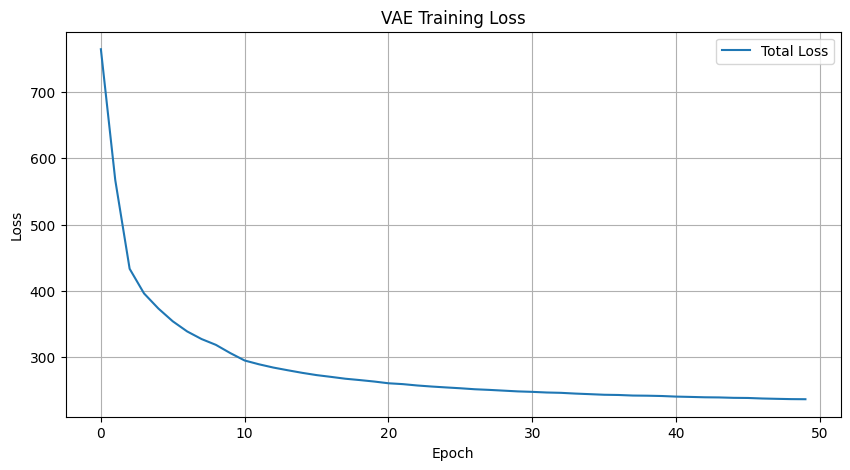

In [23]:
plt.figure(figsize=(10,5))

plt.plot(train_losses, label="Total Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss")

plt.legend()
plt.grid(True)

plt.show()

# **24. Visualize Original vs Reconstructed Cats**

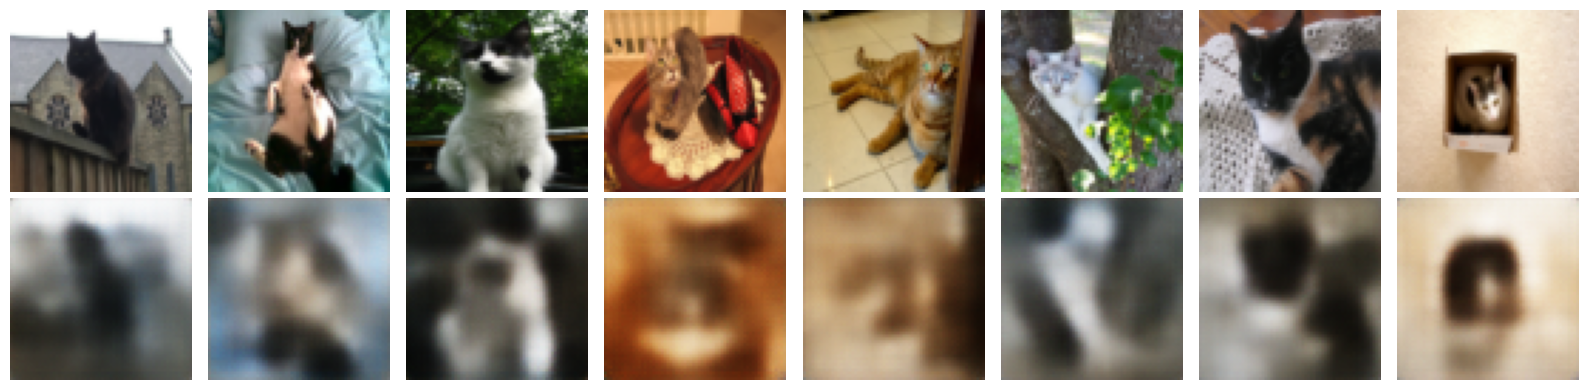

In [24]:
model.eval()

with torch.no_grad():

    images = next(iter(dataloader))[:8].to(device)

    reconstructed, _, _ = model(images)

images = images.cpu()
reconstructed = reconstructed.cpu()

plt.figure(figsize=(16,4))

for i in range(8):

    plt.subplot(2,8,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.axis("off")

    plt.subplot(2,8,i+9)
    plt.imshow(reconstructed[i].permute(1,2,0))
    plt.axis("off")

plt.tight_layout()
plt.show()

# **25. Generate New Cat Faces**

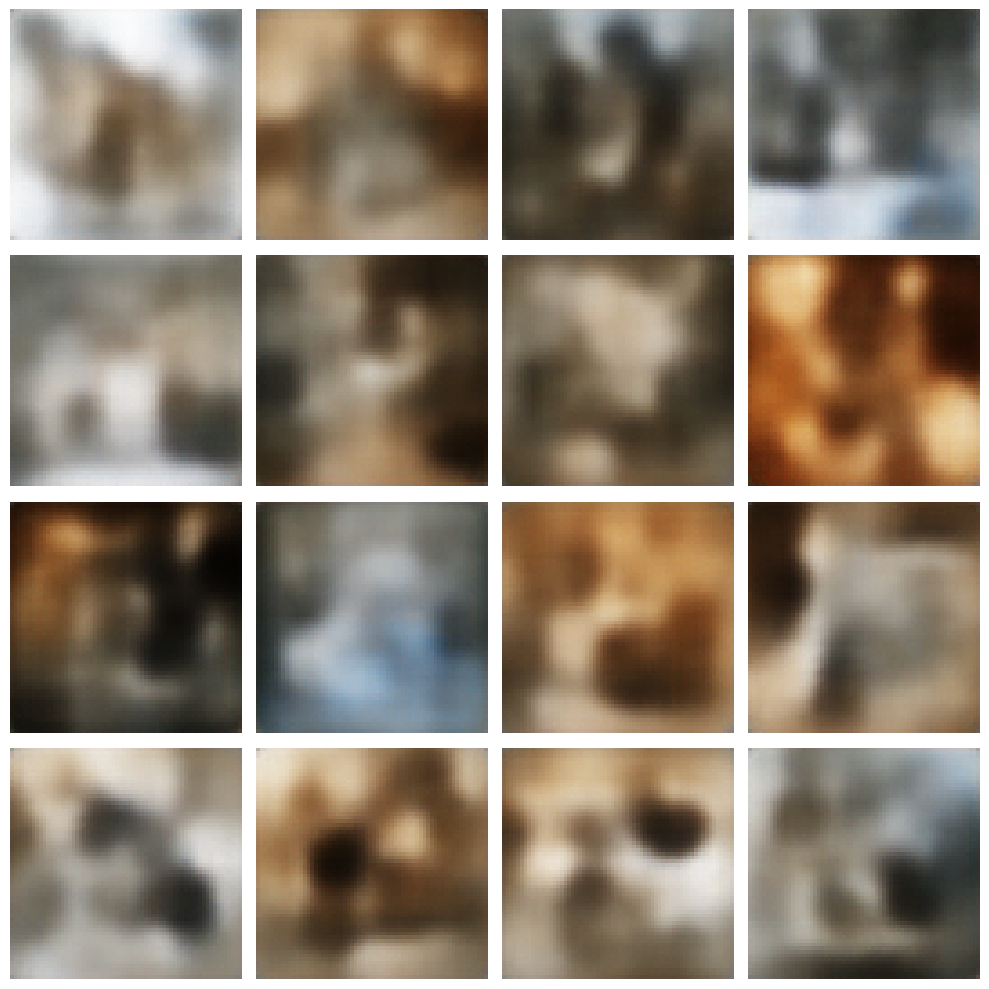

In [25]:
model.eval()

with torch.no_grad():

    z = torch.randn(16, LATENT_DIM).to(device)

    generated = model.decoder(z).cpu()

plt.figure(figsize=(10,10))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(
        generated[i].permute(1,2,0)
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# **26. Show Final Loss**

In [26]:
print("Final Loss :", train_losses[-1])
print("Final Recon:", recon_losses[-1])
print("Final KL   :", kl_losses[-1])

Final Loss : 236.44120474912006
Final Recon: 171.17454240178304
Final KL   : 65.26666212143917


# **27. Extract Latent Vectors**

In [27]:
model.eval()

latent_vectors = []

with torch.no_grad():

    for images in dataloader:

        images = images.to(device)

        mu, logvar = model.encoder(images)

        latent_vectors.append(
            mu.cpu().numpy()
        )

latent_vectors = np.concatenate(
    latent_vectors,
    axis=0
)

print("Latent Shape:", latent_vectors.shape)

Latent Shape: (9997, 128)


# **28. PCA Visualization & Reduce 128D → 2D**

In [28]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

latent_2d = pca.fit_transform(
    latent_vectors
)

print(latent_2d.shape)

(9997, 2)


# **29. Plot Latent Space**

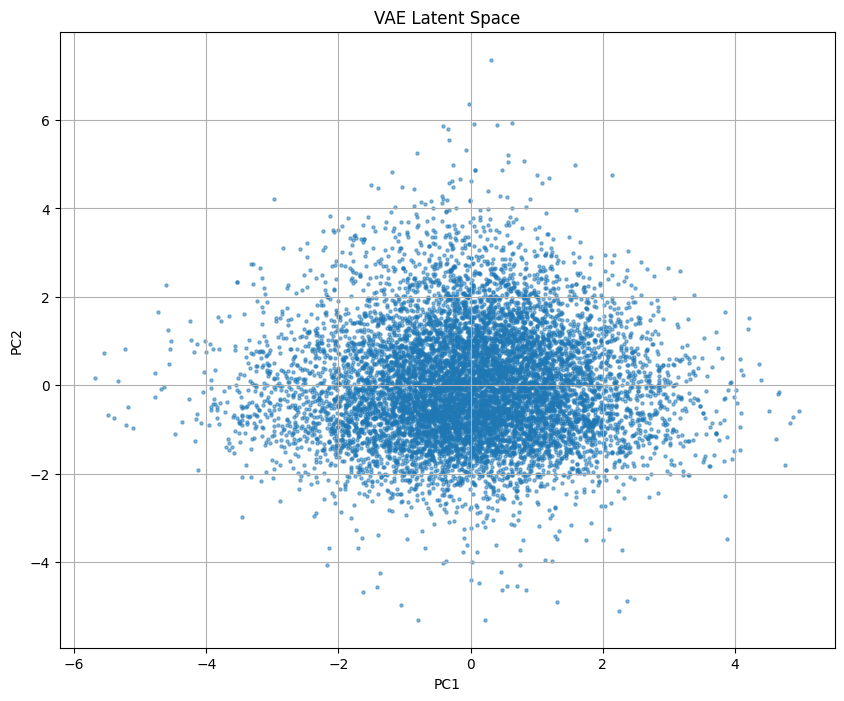

In [29]:
plt.figure(figsize=(10,8))

plt.scatter(
    latent_2d[:,0],
    latent_2d[:,1],
    s=5,
    alpha=0.5
)

plt.title("VAE Latent Space")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.grid(True)

plt.show()